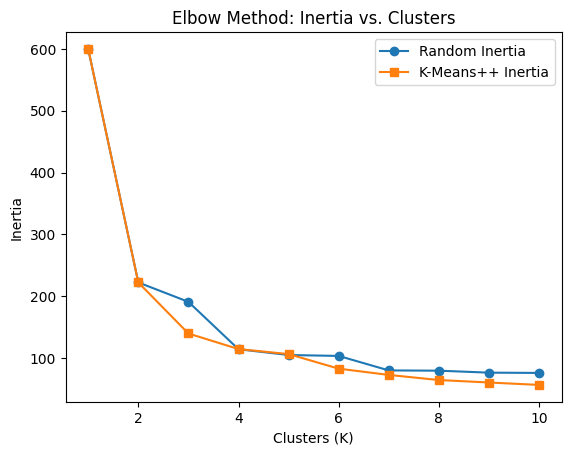

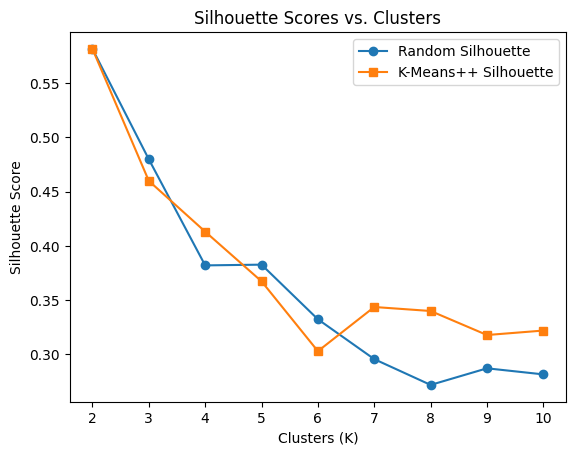

Performance Comparison:
Random Initialization:
  Optimal K by Elbow Method = 2
  Optimal K by Silhouette Score = 2
K-Means++ Initialization:
  Optimal K by Elbow Method = 2
  Optimal K by Silhouette Score = 2

Davies-Bouldin Index:
  Random Initialization = 0.5933126905760671
  K-Means++ Initialization = 0.5933126905760671

Inertia:
  Random Initialization = 222.36170496502305
  K-Means++ Initialization = 222.36170496502305


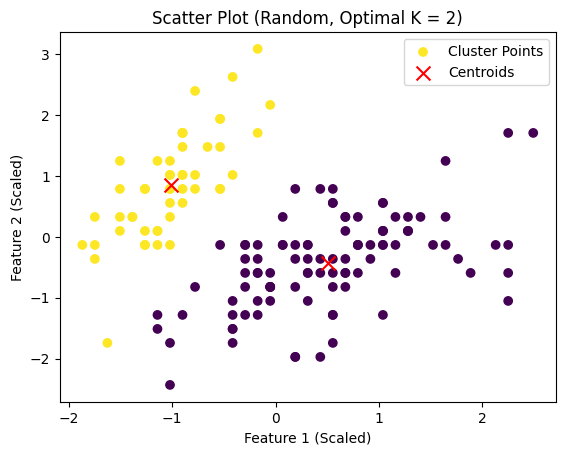

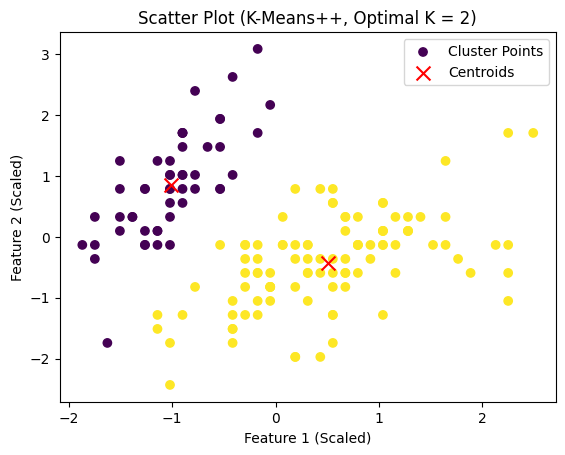

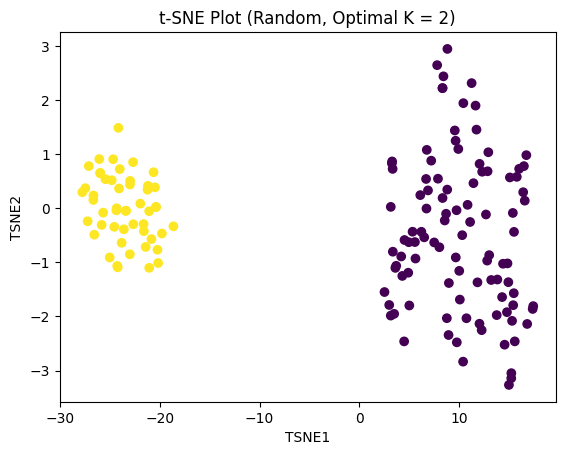

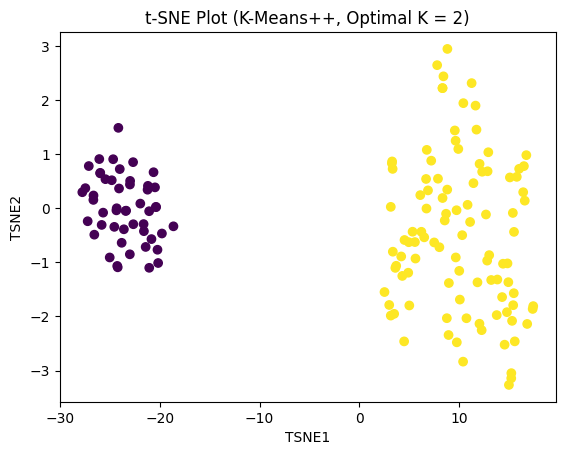

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

data = load_iris()
X = data.data
y = data.target
if np.isnan(X).any():
    cMean = np.nanmean(X, axis=0)
    idx = np.where(np.isnan(X))
    X[idx] = np.take(cMean, idx[1])
scaler = StandardScaler()
XScaled = scaler.fit_transform(X)

def distEucl(a, b):
    aSq = np.sum(a**2, axis=1).reshape(-1, 1)
    bSq = np.sum(b**2, axis=1).reshape(1, -1)  
    ab = a @ b.T                              
    d = aSq - 2 * ab + bSq                    
    d = np.maximum(d, 0.0)                    
    return np.sqrt(d)                        

def initRand(X, k, s=42):
    np.random.seed(s)
    idx = np.random.choice(len(X), k, replace=False)
    return X[idx]

def initKpp(X, k, s=42):
    np.random.seed(s)
    n = len(X)
    f = np.random.randint(0, n)
    cts = [X[f]]
    for _ in range(1, k):
        dm = distEucl(X, np.array(cts))
        mn = np.min(dm, axis=1)
        p = mn**2
        p /= np.sum(p)
        c = np.random.choice(n, p=p)
        cts.append(X[c])
    return np.array(cts)

def runKm(X, k, initM='random', mx=300, tol=1e-4, s=42):
    if initM == 'random':
        cts = initRand(X, k, s)
    else:
        cts = initKpp(X, k, s)
    for _ in range(mx):
        d = distEucl(X, cts)
        lbl = np.argmin(d, axis=1)
        newCts = []
        for i in range(k):
            pts = X[lbl == i]
            if len(pts) == 0:
                newCts.append(initRand(X, 1, s)[0])
            else:
                newCts.append(np.mean(pts, axis=0))
        newCts = np.array(newCts)
        sh = np.linalg.norm(newCts - cts) 
        cts = newCts
        if sh < tol:
            break
    return cts, lbl

def getInrt(X, cts, lbl):
    d = distEucl(X, cts)
    m = d[np.arange(len(X)), lbl]
    return np.sum(m**2)

def elbow(X, m=10, initM='random', s=42):
    ks, vals = [], []
    for k in range(1, m + 1):
        c, l = runKm(X, k, initM, s=s)
        vals.append(getInrt(X, c, l))
        ks.append(k)
    return ks, vals

def pickElbow(vals):
    diffs = []
    for i in range(1, len(vals)):
        diffs.append(vals[i - 1] - vals[i])
    iMax = np.argmax(diffs)
    return iMax + 2

def silScore(X, lbl):
    n = len(X)
    mat = distEucl(X, X)
    ulb = np.unique(lbl)
    sArr = np.zeros(n)
    for i in range(n):
        l = lbl[i]
        same = np.where(lbl == l)[0]
        a = np.mean(mat[i, same[same != i]]) if len(same) > 1 else 0.0
        b = np.inf
        for c in ulb:
            if c == l: continue
            o = np.where(lbl == c)[0]
            if len(o) > 0:
                d = np.mean(mat[i, o])
                if d < b: b = d
        sArr[i] = (b - a) / max(a, b) if max(a, b) != 0 else 0.0
    return np.mean(sArr)

def silVals(X, m=10, initM='random', s=42):
    ks, vals = [], []
    for k in range(2, m + 1):
        c, l = runKm(X, k, initM, s=s)
        vals.append(silScore(X, l))
        ks.append(k)
    return ks, vals

def pickSil(ks, vals):
    iMax = np.argmax(vals)
    return ks[iMax]

def dbIndex(X, cts, lbl):
    k = len(cts)
    sAvg = []
    for i in range(k):
        pts = X[lbl == i]
        if len(pts) == 0:
            sAvg.append(0.0)
        else:
            d = distEucl(pts, np.array([cts[i]]))
            sAvg.append(np.mean(d))
    dbSum = 0.0
    for i in range(k):
        worst = -1.0
        for j in range(k):
            if j == i: continue
            distC = np.linalg.norm(cts[i] - cts[j]) + 1e-12
            val = (sAvg[i] + sAvg[j]) / distC
            worst = max(worst, val)
        dbSum += worst
    return dbSum / k

kE, inrtRnd = elbow(XScaled, m=10, initM='random', s=2022484)
sE, silRnd = silVals(XScaled, m=10, initM='random', s=2022484)
optElbowRnd = pickElbow(inrtRnd)
optSilRnd = pickSil(sE, silRnd)

kEp, inrtPp = elbow(XScaled, m=10, initM='kmeans++', s=2022484)
sEp, silPp = silVals(XScaled, m=10, initM='kmeans++', s=2022484)
optElbowPp = pickElbow(inrtPp)
optSilPp = pickSil(sEp, silPp)

plt.figure()
plt.plot(kE, inrtRnd, marker='o', label='Random Inertia')
plt.plot(kEp, inrtPp, marker='s', label='K-Means++ Inertia')
plt.xlabel('Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Inertia vs. Clusters')
plt.legend()
plt.show()

plt.figure()
plt.plot(sE, silRnd, marker='o', label='Random Silhouette')
plt.plot(sEp, silPp, marker='s', label='K-Means++ Silhouette')
plt.xlabel('Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores vs. Clusters')
plt.legend()
plt.show()

print("Performance Comparison:")
print("Random Initialization:")
print("  Optimal K by Elbow Method =", optElbowRnd)
print("  Optimal K by Silhouette Score =", optSilRnd)
print("K-Means++ Initialization:")
print("  Optimal K by Elbow Method =", optElbowPp)
print("  Optimal K by Silhouette Score =", optSilPp)

cRnd, lRnd = runKm(XScaled, optSilRnd, 'random', s=42)
cPp, lPp = runKm(XScaled, optSilPp, 'kmeans++', s=7)

dbRnd = dbIndex(XScaled, cRnd, lRnd)
dbPp = dbIndex(XScaled, cPp, lPp)
print("\nDavies-Bouldin Index:")
print("  Random Initialization =", dbRnd)
print("  K-Means++ Initialization =", dbPp)

inrtRndOpt = getInrt(XScaled, cRnd, lRnd)
inrtPpOpt = getInrt(XScaled, cPp, lPp)
print("\nInertia:")
print("  Random Initialization =", inrtRndOpt)
print("  K-Means++ Initialization =", inrtPpOpt)

plt.figure()
plt.scatter(XScaled[:, 0], XScaled[:, 1], c=lRnd, marker='o', label='Cluster Points')
plt.scatter(cRnd[:, 0], cRnd[:, 1], c='red', marker='x', s=100, label='Centroids')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title(f'Scatter Plot (Random, Optimal K = {optSilRnd})')
plt.legend()
plt.show()

plt.figure()
plt.scatter(XScaled[:, 0], XScaled[:, 1], c=lPp, marker='o', label='Cluster Points')
plt.scatter(cPp[:, 0], cPp[:, 1], c='red', marker='x', s=100, label='Centroids')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title(f'Scatter Plot (K-Means++, Optimal K = {optSilPp})')
plt.legend()
plt.show()

tsne = TSNE(n_components=2, random_state=42)
XTsne = tsne.fit_transform(XScaled)
plt.figure()
plt.scatter(XTsne[:, 0], XTsne[:, 1], c=lRnd)
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.title(f't-SNE Plot (Random, Optimal K = {optSilRnd})')
plt.show()

plt.figure()
plt.scatter(XTsne[:, 0], XTsne[:, 1], c=lPp)
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.title(f't-SNE Plot (K-Means++, Optimal K = {optSilPp})')
plt.show()

# Performance Comparison Report

For the Iris dataset, both random and k-means++ initialization methods resulted in an optimal K of 2, as determined by both the Elbow method and Silhouette scores. The Davies-Bouldin Index was identical (≈0.5933) for both approaches, indicating that the final clusters are of similar quality. Additionally, the inertia values were identical (≈222.36), confirming that the clusters are equally compact. The silhouette scores further indicate that the clusters are well-separated, and visualizations using scatter plots and t-SNE support these findings with similar cluster formations observed for both initialization methods. Overall, the clustering outcome appears robust to the choice of initialization on this dataset. While k-means++ is generally favored for more complex datasets to help avoid poor local minima, in this case, both methods perform equivalently.